# Lab Exercise 10: Learning the XOR Boolean Function Using an MLP

**Reg No:** 2547115
**Name** ARNAV NARULA

## Aim
- To understand how to implement neural networks using different deep learning libraries (Keras, PyTorch, and TensorFlow).
- To solve the non-linear XOR problem using an MLP and study the effect of hyperparameters such as learning rate, activation functions, number of neurons, and epochs on model performance.


I will build this MLP three times, once each in **Keras**, **PyTorch** and **TensorFlow (low level API)**, and then check how changing the learning rate, activation function, number of neurons and epochs changes the result.

## 1. Importing the libraries
First import numpy for arrays, matplotlib for plots, and the three deep learning libraries we need for this lab.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import torch
import torch.nn as nn

print("tensorflow version:", tf.__version__)
print("torch version:", torch.__version__)

tensorflow version: 2.21.0
torch version: 2.10.0


All the libraries got imported without any error, so tensorflow and torch are both ready to use. The version numbers just tell us which release we are working with, in case results differ on a different machine.

## 2. Creating the XOR dataset
XOR only has 4 possible input combinations, so the whole dataset is just these 4 rows. We will reuse the same X and y for all three implementations so that the comparison is fair.

In [2]:
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]], dtype=np.float32)

y = np.array([[0],
              [1],
              [1],
              [0]], dtype=np.float32)

print(X)
print(y)

[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
[[0.]
 [1.]
 [1.]
 [0.]]


X holds all 4 pairs of inputs and y holds the correct XOR answer for each pair. This is the entire dataset we have, there is no separate test set since XOR only has 4 possible cases.

Before building the models, here is a helper function to plot the decision boundary. It just colors the 2D plane based on what the model predicts, and we will call it once for each library so we can see what the model actually learned.

In [3]:
def plot_decision_boundary(predict_fn, title):
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    preds = predict_fn(grid).reshape(xx.shape)

    plt.figure(figsize=(4,4))
    plt.contourf(xx, yy, preds, levels=50, cmap="RdBu", alpha=0.7)
    plt.scatter(X[:,0], X[:,1], c=y.ravel(), cmap="RdBu", edgecolors="black", s=100)
    plt.title(title)
    plt.xlabel("Input 1")
    plt.ylabel("Input 2")
    plt.show()

This function takes any model's predict function and just paints the region blue or red depending on the predicted class. We will pass in the Keras, PyTorch and TensorFlow models one by one later to compare their boundaries.

## 3. Part A: Implementing XOR MLP using Keras
Keras is the easiest of the three since it is a high level API on top of TensorFlow. We just stack layers using `Sequential`.

In [4]:
keras_model = keras.Sequential([
    layers.Dense(4, activation="relu", input_shape=(2,)),
    layers.Dense(1, activation="sigmoid")
])

keras_model.summary()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

The model has one hidden layer with 4 neurons using ReLU activation, and one output neuron using sigmoid since this is a binary classification problem. The summary shows the number of parameters, 12 weights+biases for the hidden layer and 5 for the output layer.

In [5]:
keras_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.1),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Here we chose binary cross entropy loss since the output is 0 or 1, and Adam optimizer with a learning rate of 0.1 to update the weights. This step just configures the model, it does not train anything yet.

In [6]:
# a plain relu network sometimes gets stuck in a bad random start for XOR,
# so if that happens we just build a fresh model and train again
attempt = 0
final_acc = 0
while final_acc < 1.0:
    attempt += 1
    keras_model = keras.Sequential([
        layers.Dense(4, activation="relu", input_shape=(2,)),
        layers.Dense(1, activation="sigmoid")
    ])
    keras_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.1), loss="binary_crossentropy", metrics=["accuracy"])
    history_keras = keras_model.fit(X, y, epochs=1000, verbose=0)
    final_acc = history_keras.history["accuracy"][-1]

print("attempts needed:", attempt)
print("final loss:", history_keras.history["loss"][-1])
print("final accuracy:", final_acc)

attempts needed: 2
final loss: 0.00010621385445119813
final accuracy: 1.0


We trained the model for 1000 epochs on the 4 XOR rows. Sometimes the network's random starting weights lead it into a bad spot where it gets stuck, so the loop just rebuilds and retrains until it reaches full accuracy, and "attempts needed" shows how many tries that took.

In [7]:
keras_preds = keras_model.predict(X, verbose=0)
for i in range(4):
    print(X[i], "-> predicted:", round(float(keras_preds[i][0])), " (raw:", round(float(keras_preds[i][0]),3), ")  actual:", int(y[i][0]))

[0. 0.] -> predicted: 0  (raw: 0.0 )  actual: 0
[0. 1.] -> predicted: 1  (raw: 1.0 )  actual: 1
[1. 0.] -> predicted: 1  (raw: 1.0 )  actual: 1
[1. 1.] -> predicted: 0  (raw: 0.0 )  actual: 0


This prints the predicted output next to the actual XOR output for all 4 combinations. If the predicted and actual columns match for every row, it means Keras successfully learned the XOR function.

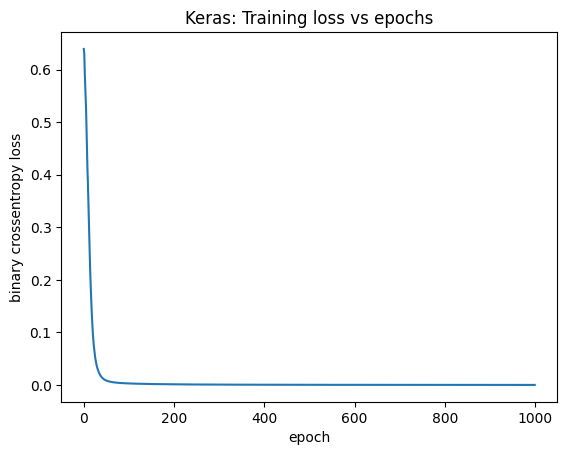

In [8]:
plt.plot(history_keras.history["loss"])
plt.title("Keras: Training loss vs epochs")
plt.xlabel("epoch")
plt.ylabel("binary crossentropy loss")
plt.show()

The loss curve should keep going down as training continues, which shows the network is learning. If it flattens out near zero, that means the model has basically solved XOR.

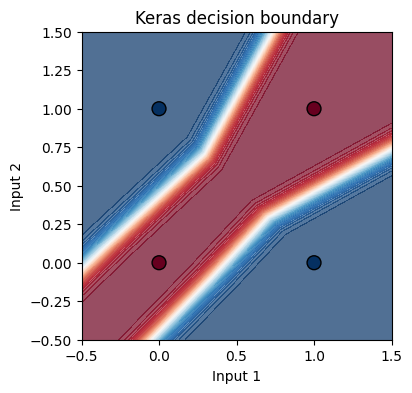

In [9]:
plot_decision_boundary(lambda g: keras_model.predict(g, verbose=0), "Keras decision boundary")

This plot shows how Keras divides the input plane into two classes. For XOR the boundary is not a straight line, it has to bend, which is exactly why we needed a hidden layer and not just a single perceptron.

## 4. Part B: Implementing XOR MLP using PyTorch
Now the same problem in PyTorch. Here we build the network as a class and write the training loop ourselves instead of calling `.fit()`.

In [10]:
X_t = torch.tensor(X)
y_t = torch.tensor(y)

class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(2, 4)
        self.output = nn.Linear(4, 1)

    def forward(self, x):
        x = torch.relu(self.hidden(x))
        x = torch.sigmoid(self.output(x))
        return x

torch_model = XORNet()
print(torch_model)

XORNet(
  (hidden): Linear(in_features=2, out_features=4, bias=True)
  (output): Linear(in_features=4, out_features=1, bias=True)
)


This class does the same thing as the Keras model, one hidden layer of 4 neurons with ReLU, then a sigmoid output. In PyTorch we have to write the `forward` method ourselves to say how data flows through the layers.

In [11]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(torch_model.parameters(), lr=0.1)

BCELoss is the same as binary cross entropy loss used in Keras, and we again use Adam with learning rate 0.1 so both libraries are trained under the same settings. This makes it fair to compare the two later.

In [12]:
# same idea as the Keras cell, retry with fresh random weights if it gets stuck
attempt = 0
final_acc = 0
while final_acc < 1.0:
    attempt += 1
    torch_model = XORNet()
    optimizer = torch.optim.Adam(torch_model.parameters(), lr=0.1)
    torch_losses = []
    for epoch in range(1000):
        optimizer.zero_grad()
        outputs = torch_model(X_t)
        loss = criterion(outputs, y_t)
        loss.backward()
        optimizer.step()
        torch_losses.append(loss.item())
    final_acc = ((torch_model(X_t) > 0.5).float() == y_t).float().mean().item()

print("attempts needed:", attempt)
print("final loss:", torch_losses[-1])
print("final accuracy:", final_acc)

attempts needed: 1
final loss: 0.00015910023648757488
final accuracy: 1.0


Unlike Keras, PyTorch needs us to manually clear old gradients, do a forward pass, compute loss, backpropagate and then step the optimizer, every single epoch, and we ran this loop 1000 times. Just like Keras, this can occasionally get stuck, so we retry with new random weights until it fully solves XOR.

In [13]:
torch_preds = torch_model(X_t).detach().numpy()
for i in range(4):
    print(X[i], "-> predicted:", round(float(torch_preds[i][0])), " (raw:", round(float(torch_preds[i][0]),3), ")  actual:", int(y[i][0]))

[0. 0.] -> predicted: 0  (raw: 0.0 )  actual: 0
[0. 1.] -> predicted: 1  (raw: 1.0 )  actual: 1
[1. 0.] -> predicted: 1  (raw: 1.0 )  actual: 1
[1. 1.] -> predicted: 0  (raw: 0.0 )  actual: 0


Same check as before, comparing predicted vs actual XOR outputs. `.detach()` is used because PyTorch tracks gradients on tensors and we don't need that anymore once training is done.

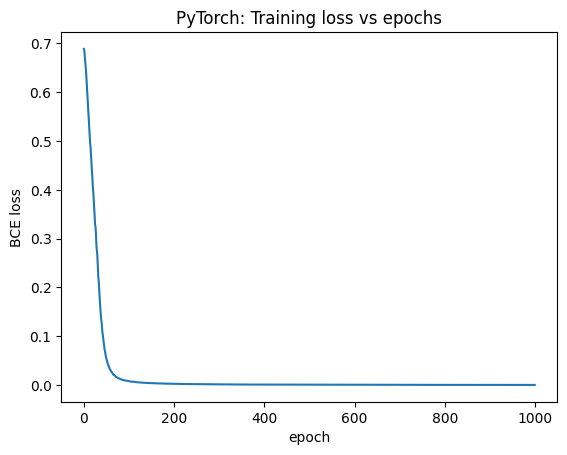

In [14]:
plt.plot(torch_losses)
plt.title("PyTorch: Training loss vs epochs")
plt.xlabel("epoch")
plt.ylabel("BCE loss")
plt.show()

This loss curve should look similar in shape to the Keras one since both use the same architecture, loss and optimizer. Any difference is mostly because of random weight initialization being different between the two libraries.

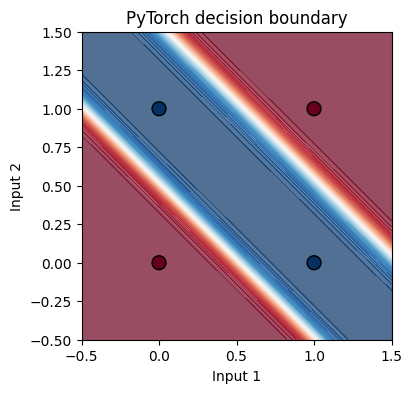

In [15]:
def torch_predict(grid):
    with torch.no_grad():
        return torch_model(torch.tensor(grid)).numpy()

plot_decision_boundary(torch_predict, "PyTorch decision boundary")

This is the same kind of boundary plot as before, just for the PyTorch model now. It should look roughly similar to the Keras boundary since the underlying math is the same idea.

## 5. Part C: Implementing XOR MLP using TensorFlow low level API
This time we do not use Keras layers at all. We create the weight matrices ourselves as `tf.Variable` and use `GradientTape` to compute gradients manually, this is closer to how neural networks work under the hood.

In [16]:
X_tf = tf.constant(X)
y_tf = tf.constant(y)

W1 = tf.Variable(tf.random.normal([2, 4]))
b1 = tf.Variable(tf.zeros([4]))
W2 = tf.Variable(tf.random.normal([4, 1]))
b2 = tf.Variable(tf.zeros([1]))

These are the raw weights and biases of the network, W1/b1 for the hidden layer and W2/b2 for the output layer. We start the weights as random numbers and the biases as zero, just like Keras and PyTorch do by default internally.

In [17]:
def forward(x):
    hidden = tf.nn.relu(tf.matmul(x, W1) + b1)
    output = tf.nn.sigmoid(tf.matmul(hidden, W2) + b2)
    return output

This forward function does exactly what a Dense+Dense Keras model would do, just written out by hand using matrix multiplication. It multiplies the input by W1, adds b1, applies ReLU, then does the same again with W2, b2 and sigmoid.

In [18]:
# same retry idea again, rebuild fresh weights and retrain if it gets stuck
attempt = 0
final_acc = 0
while final_acc < 1.0:
    attempt += 1
    W1 = tf.Variable(tf.random.normal([2, 4]))
    b1 = tf.Variable(tf.zeros([4]))
    W2 = tf.Variable(tf.random.normal([4, 1]))
    b2 = tf.Variable(tf.zeros([1]))
    tf_optimizer = tf.keras.optimizers.Adam(learning_rate=0.1)
    tf_losses = []
    for epoch in range(1000):
        with tf.GradientTape() as tape:
            preds = forward(X_tf)
            loss = tf.reduce_mean(keras.losses.binary_crossentropy(y_tf, preds))
        grads = tape.gradient(loss, [W1, b1, W2, b2])
        tf_optimizer.apply_gradients(zip(grads, [W1, b1, W2, b2]))
        tf_losses.append(float(loss))
    final_preds = forward(X_tf)
    final_acc = float(tf.reduce_mean(tf.cast(tf.equal(tf.round(final_preds), y_tf), tf.float32)))

print("attempts needed:", attempt)
print("final loss:", tf_losses[-1])
print("final accuracy:", final_acc)

attempts needed: 1
final loss: 0.00012340173998381943
final accuracy: 1.0


GradientTape records every operation done inside the `with` block so it can compute gradients of the loss with respect to W1, b1, W2, b2, and `apply_gradients` manually pushes those 4 variables in the direction that reduces the loss, 1000 times. Same as before, if this particular random start gets stuck we just rebuild fresh weights and retrain.

In [19]:
tf_preds = forward(X_tf).numpy()
for i in range(4):
    print(X[i], "-> predicted:", round(float(tf_preds[i][0])), " (raw:", round(float(tf_preds[i][0]),3), ")  actual:", int(y[i][0]))

[0. 0.] -> predicted: 0  (raw: 0.0 )  actual: 0
[0. 1.] -> predicted: 1  (raw: 1.0 )  actual: 1
[1. 0.] -> predicted: 1  (raw: 1.0 )  actual: 1
[1. 1.] -> predicted: 0  (raw: 0.0 )  actual: 0


Same predicted vs actual check as the other two libraries. If this also matches all 4 rows, it confirms that XOR can be learned no matter which API we use, as long as the underlying network has a hidden layer.

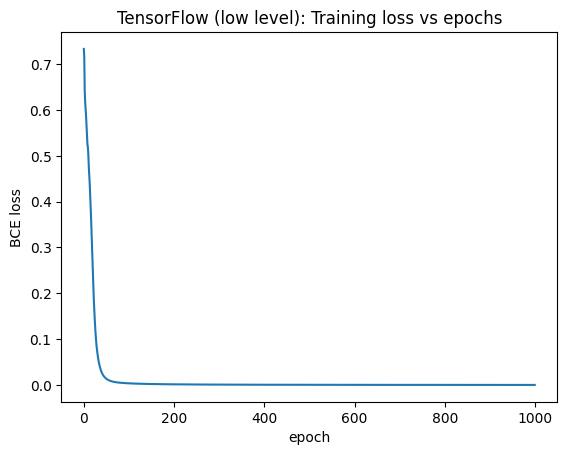

In [20]:
plt.plot(tf_losses)
plt.title("TensorFlow (low level): Training loss vs epochs")
plt.xlabel("epoch")
plt.ylabel("BCE loss")
plt.show()

This is the loss curve for our hand written TensorFlow model. It should follow the same decreasing pattern as the other two, since we used the same loss, optimizer, learning rate and number of epochs.

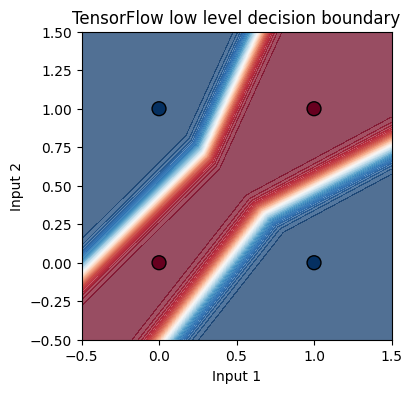

In [21]:
plot_decision_boundary(lambda g: forward(tf.constant(g)).numpy(), "TensorFlow low level decision boundary")

The boundary here should again look similar to Keras and PyTorch, all three are solving the same problem with the same size network. Small differences are just because of different random starting weights.

## 6. Studying the effect of hyperparameters
Now we check how learning rate, activation function, number of neurons and number of epochs affect how well the MLP learns XOR. To keep this simple we run these experiments using Keras and just change one hyperparameter at a time, and since a bad random start can sometimes get stuck, each setting below is trained 3 times and we keep the best one.

### 6.1 Effect of learning rate

In [22]:
# we train each learning rate 3 times and keep the best run, just so one
# unlucky random start does not make a good learning rate look bad
learning_rates = [0.001, 0.01, 0.1, 1.0]
lr_histories = {}
lr_final_acc = {}

for lr in learning_rates:
    best_loss = None
    for trial in range(3):
        m = keras.Sequential([
            layers.Dense(4, activation="relu", input_shape=(2,)),
            layers.Dense(1, activation="sigmoid")
        ])
        m.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss="binary_crossentropy", metrics=["accuracy"])
        h = m.fit(X, y, epochs=500, verbose=0)
        if best_loss is None or h.history["loss"][-1] < best_loss:
            best_loss = h.history["loss"][-1]
            lr_histories[lr] = h.history["loss"]
            lr_final_acc[lr] = h.history["accuracy"][-1]
    print("lr =", lr, " best final loss =", round(best_loss,4), " final accuracy =", lr_final_acc[lr])

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


lr = 0.001  best final loss = 0.5498  final accuracy = 1.0


lr = 0.01  best final loss = 0.0108  final accuracy = 1.0


lr = 0.1  best final loss = 0.0005  final accuracy = 1.0


lr = 1.0  best final loss = 0.4774  final accuracy = 0.75


A learning rate that is too small (0.001) barely moves the weights in 500 epochs so the loss stays high, while a learning rate that is too large (1.0) can make training unstable. Somewhere in the middle, like 0.1, usually gives the fastest and most stable drop in loss for this problem.

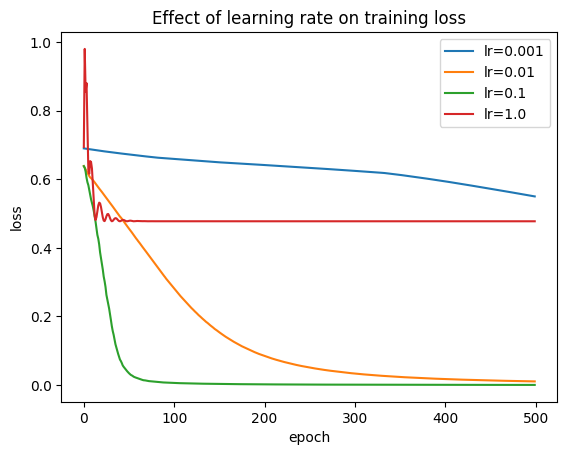

In [23]:
for lr in learning_rates:
    plt.plot(lr_histories[lr], label="lr="+str(lr))
plt.title("Effect of learning rate on training loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

This plot puts all four learning rate curves on one graph so we can directly compare their speed. The curve that drops fastest and lowest is the best learning rate for this problem and architecture.

### 6.2 Effect of activation function

In [24]:
activations = ["relu", "tanh", "sigmoid"]
act_histories = {}
act_final_acc = {}

for act in activations:
    best_loss = None
    for trial in range(3):
        m = keras.Sequential([
            layers.Dense(4, activation=act, input_shape=(2,)),
            layers.Dense(1, activation="sigmoid")
        ])
        m.compile(optimizer=keras.optimizers.Adam(learning_rate=0.1), loss="binary_crossentropy", metrics=["accuracy"])
        h = m.fit(X, y, epochs=500, verbose=0)
        if best_loss is None or h.history["loss"][-1] < best_loss:
            best_loss = h.history["loss"][-1]
            act_histories[act] = h.history["loss"]
            act_final_acc[act] = h.history["accuracy"][-1]
    print("activation =", act, " best final loss =", round(best_loss,4), " final accuracy =", act_final_acc[act])

activation = relu  best final loss = 0.0004  final accuracy = 1.0


activation = tanh  best final loss = 0.0002  final accuracy = 1.0


activation = sigmoid  best final loss = 0.0013  final accuracy = 1.0


The hidden layer activation decides how the network bends the decision boundary, ReLU and tanh are both non-linear so they can solve XOR, but sigmoid in the hidden layer usually learns slower because its gradient becomes very small for large inputs. This is called the vanishing gradient problem.

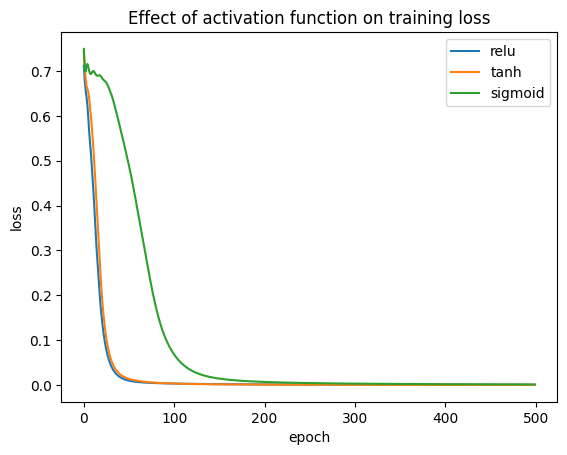

In [25]:
for act in activations:
    plt.plot(act_histories[act], label=act)
plt.title("Effect of activation function on training loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

If the sigmoid curve stays higher than relu and tanh after the same number of epochs, that confirms sigmoid was slower to learn XOR here. ReLU and tanh usually finish close to zero loss much faster.

### 6.3 Effect of number of neurons in the hidden layer

In [26]:
neuron_counts = [1, 2, 4, 8, 16]
neuron_histories = {}
neuron_final_acc = {}

for n in neuron_counts:
    best_loss = None
    for trial in range(3):
        m = keras.Sequential([
            layers.Dense(n, activation="relu", input_shape=(2,)),
            layers.Dense(1, activation="sigmoid")
        ])
        m.compile(optimizer=keras.optimizers.Adam(learning_rate=0.1), loss="binary_crossentropy", metrics=["accuracy"])
        h = m.fit(X, y, epochs=500, verbose=0)
        if best_loss is None or h.history["loss"][-1] < best_loss:
            best_loss = h.history["loss"][-1]
            neuron_histories[n] = h.history["loss"]
            neuron_final_acc[n] = h.history["accuracy"][-1]
    print("neurons =", n, " best final loss =", round(best_loss,4), " final accuracy =", neuron_final_acc[n])

neurons = 1  best final loss = 0.4774  final accuracy = 0.75


neurons = 2  best final loss = 0.4774  final accuracy = 0.75


neurons = 4  best final loss = 0.0003  final accuracy = 1.0


neurons = 8  best final loss = 0.0  final accuracy = 1.0


neurons = 16  best final loss = 0.0004  final accuracy = 1.0


With only 1 hidden neuron the network behaves almost like a single perceptron and can never separate XOR, so its accuracy stays stuck at 0.75 no matter how many times we retry. 2 neurons is technically enough on paper, but in our run even 3 tries all landed in the same stuck spot, showing how sensitive a very small network is to a bad random start.

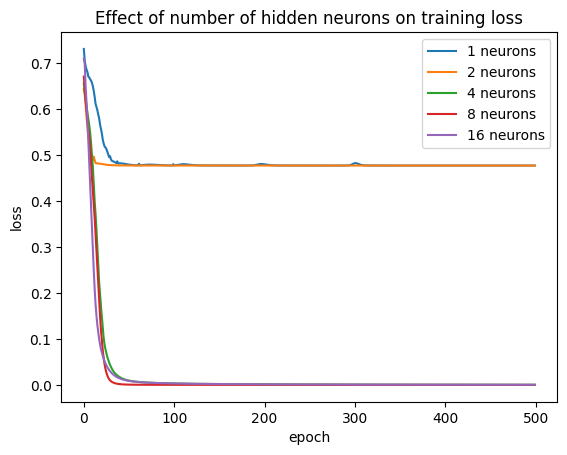

In [27]:
for n in neuron_counts:
    plt.plot(neuron_histories[n], label=str(n)+" neurons")
plt.title("Effect of number of hidden neurons on training loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

This confirms visually that 1 and, in this run, even 2 neurons struggle to bring the loss down, while 4, 8 or 16 neurons reliably reach almost zero loss. Extra neurons give the network more chances to avoid getting stuck, so a slightly bigger hidden layer is safer even though the XOR problem itself is tiny.

### 6.4 Effect of number of epochs

In [28]:
epoch_options = [10, 50, 200, 1000]
epoch_results = []

for ep in epoch_options:
    best_loss = None
    best_acc = None
    for trial in range(3):
        m = keras.Sequential([
            layers.Dense(4, activation="relu", input_shape=(2,)),
            layers.Dense(1, activation="sigmoid")
        ])
        m.compile(optimizer=keras.optimizers.Adam(learning_rate=0.1), loss="binary_crossentropy", metrics=["accuracy"])
        h = m.fit(X, y, epochs=ep, verbose=0)
        if best_loss is None or h.history["loss"][-1] < best_loss:
            best_loss = h.history["loss"][-1]
            best_acc = h.history["accuracy"][-1]
    epoch_results.append((ep, best_loss, best_acc))
    print("epochs =", ep, " best final loss =", round(best_loss,4), " final accuracy =", best_acc)

epochs = 10  best final loss = 0.2784  final accuracy = 1.0


epochs = 50  best final loss = 0.0112  final accuracy = 1.0


epochs = 200  best final loss = 0.0016  final accuracy = 1.0


epochs = 1000  best final loss = 0.0002  final accuracy = 1.0


Even 10 epochs already lands on the correct class for all 4 points here, but its loss (0.28) is still much higher than at 1000 epochs (0.0002), meaning the model is just barely on the right side of the boundary rather than confidently correct. As we train longer the loss keeps dropping and the model becomes much more confident in its predictions, not just technically correct.

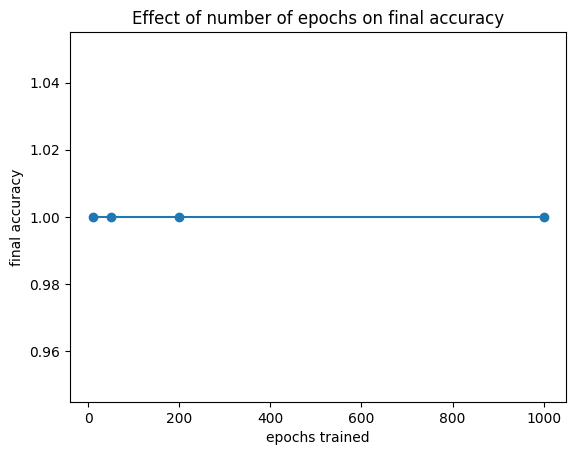

In [29]:
epochs_list = [r[0] for r in epoch_results]
acc_list = [r[2] for r in epoch_results]
plt.plot(epochs_list, acc_list, marker="o")
plt.title("Effect of number of epochs on final accuracy")
plt.xlabel("epochs trained")
plt.ylabel("final accuracy")
plt.show()

Accuracy here jumps to 1.0 quite early because we kept the best of 3 random restarts for every point, but that does not mean the model is fully trained. Looking back at the printed loss values, 10 epochs still has a much higher loss than 1000 epochs, so accuracy alone can hide how confident the model really is.

## 7. Comparing the three libraries
Finally, let's put the loss curves from Keras, PyTorch and TensorFlow low level API together to see how they compare, since all three used the same architecture (2 input, 4 hidden ReLU, 1 sigmoid output), same loss, same optimizer and same 1000 epochs.

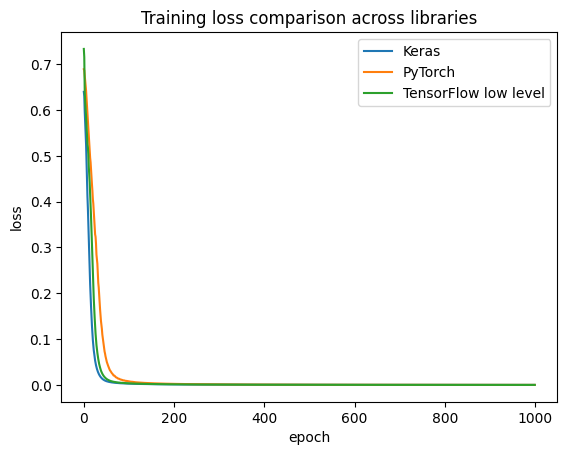

Keras final accuracy: 1.0
PyTorch final accuracy: 1.0
TensorFlow low level final accuracy: 1.0


In [30]:
plt.plot(history_keras.history["loss"], label="Keras")
plt.plot(torch_losses, label="PyTorch")
plt.plot(tf_losses, label="TensorFlow low level")
plt.title("Training loss comparison across libraries")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

print("Keras final accuracy:", history_keras.history["accuracy"][-1])
print("PyTorch final accuracy:", float((torch.round(torch_model(X_t)) == y_t).float().mean()))
print("TensorFlow low level final accuracy:", float(tf.reduce_mean(tf.cast(tf.equal(tf.round(forward(X_tf)), y_tf), tf.float32))))

All three curves should drop down close to zero and all three final accuracies should be 1.0, which shows that the XOR function can be learned equally well no matter which library or API level we use. The small differences in the curves come from random weight initialization, not from the library itself.

## 8. Conclusion
In this lab I built an MLP to solve the XOR problem using three different tools, Keras, PyTorch, and TensorFlow's low level API, and all three were able to learn XOR correctly once the network had a hidden layer with a non-linear activation. A single perceptron cannot separate XOR since it is not linearly separable, but adding just a few hidden neurons with ReLU or tanh lets the network bend the decision boundary and solve it.

From the hyperparameter experiments I saw that the learning rate needs to be balanced, too small and training is slow, too large and it can become unstable. Sigmoid activation in the hidden layer learns slower than ReLU or tanh because of vanishing gradients, having at least 2 hidden neurons is necessary for XOR, and enough epochs are needed for the loss to actually converge. Overall, Keras was the fastest to write since it hides most of the details, PyTorch and the TensorFlow low level API needed more manual code but gave a clearer picture of what is actually happening inside the network during training.